In [2]:
# Core libraries

import numpy as np
import pandas as pd

# Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Statistics

from scipy import stats

# Scikit-learn

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    FunctionTransformer
)

from sklearn.feature_selection import (
    mutual_info_classif,
    SelectKBest,
    chi2
)

from sklearn.ensemble import RandomForestClassifier

In [3]:
# Load Titanic dataset

titanic = fetch_openml(
    name="titanic",
    version=1,
    as_frame=True
)

df_raw = titanic.frame.copy()

df_raw["survived"] = pd.to_numeric(
    df_raw["survived"],
    errors="coerce"
)
print(df_raw.shape)
print(df_raw.dtypes)
df_raw.head()


(1309, 14)
pclass          int64
survived        int64
name              str
sex          category
age           float64
sibsp           int64
parch           int64
ticket            str
fare          float64
cabin             str
embarked     category
boat              str
body          float64
home.dest         str
dtype: object


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [4]:
# Dataset overview

print("Shape:")
print(df_raw.shape)

print("\nInfo:")
df_raw.info()

print("\nData types:")
print(df_raw.dtypes)

print("\nFirst rows:")
display(df_raw.head())

print("\nLast rows:")
display(df_raw.tail())

Shape:
(1309, 14)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   int64   
 1   survived   1309 non-null   int64   
 2   name       1309 non-null   str     
 3   sex        1309 non-null   category
 4   age        1046 non-null   float64 
 5   sibsp      1309 non-null   int64   
 6   parch      1309 non-null   int64   
 7   ticket     1309 non-null   str     
 8   fare       1308 non-null   float64 
 9   cabin      295 non-null    str     
 10  embarked   1307 non-null   category
 11  boat       486 non-null    str     
 12  body       121 non-null    float64 
 13  home.dest  745 non-null    str     
dtypes: category(2), float64(3), int64(4), str(5)
memory usage: 125.4 KB

Data types:
pclass          int64
survived        int64
name              str
sex          category
age           float64
sibsp           int64
parch

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"



Last rows:


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
1304,3,0,"Zabour, Miss. Hileni",female,14.5,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",male,27.0,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN
1308,3,0,"Zimmerman, Mr. Leo",male,29.0,0,0,315082,7.8750,NaN,S,NaN,NaN,NaN


In [5]:
# Memory usage

memory_usage = (
    df_raw.memory_usage(deep=True)
    .sort_values(ascending=False)
)

print(memory_usage)

print(
    "\nTotal memory:",
    round(memory_usage.sum() / 1024, 2),
    "KB"
)

name         99651
ticket       73030
home.dest    68831
boat         50872
cabin        48006
pclass       10472
survived     10472
age          10472
sibsp        10472
parch        10472
fare         10472
body         10472
embarked      1459
sex           1417
Index          132
dtype: int64

Total memory: 406.94 KB


In [6]:
# Numeric statistics

display(
    df_raw.describe(
        include="all"
    ).T
)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
pclass,1309.0,NaN,NaN,NaN,2.294882,0.837836,1.0,2.0,3.0,3.0,3.0
survived,1309.0,NaN,NaN,NaN,0.381971,0.486055,0.0,0.0,0.0,1.0,1.0
name,1309,1307,"Connolly, Miss. Kate",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,1309,2,male,843,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1046.0,NaN,NaN,NaN,29.881135,14.4135,0.1667,21.0,28.0,39.0,80.0
sibsp,1309.0,NaN,NaN,NaN,0.498854,1.041658,0.0,0.0,0.0,1.0,8.0
parch,1309.0,NaN,NaN,NaN,0.385027,0.86556,0.0,0.0,0.0,0.0,9.0
ticket,1309,929,CA. 2343,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fare,1308.0,NaN,NaN,NaN,33.295479,51.758668,0.0,7.8958,14.4542,31.275,512.3292
cabin,295,186,C23 C25 C27,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Check unique ratios

unique_summary = pd.DataFrame({
    "unique_count": df_raw.nunique(),
    "unique_ratio": df_raw.nunique() / len(df_raw)
})

display(
    unique_summary
    .sort_values("unique_ratio", ascending=False)
)

,unique_count,unique_ratio
name,1307,0.998472
ticket,929,0.709702
home.dest,369,0.281895
fare,281,0.214668
cabin,186,0.142093
body,121,0.092437
age,98,0.074866
boat,27,0.020626
parch,8,0.006112
sibsp,7,0.005348


In [8]:
# Check fully empty columns

fully_empty = df_raw.columns[
    df_raw.isnull().all()
]

print("Fully empty columns:")
print(fully_empty.tolist())


Fully empty columns:
[]


In [9]:
# Check duplicate rows

duplicate_rows = df_raw.duplicated().sum()

print(
    "Duplicate rows:",
    duplicate_rows
)

Duplicate rows: 0


In [10]:
# Check duplicate columns

duplicate_columns = df_raw.T.duplicated()

print(
    df_raw.columns[
        duplicate_columns
    ].tolist()
)

[]


In [11]:
# Missing value summary

missing_summary = pd.DataFrame({
    "missing_count":
        df_raw.isnull().sum(),

    "missing_percentage":
        df_raw.isnull().mean() * 100
})

missing_summary = (
    missing_summary[
        missing_summary[
            "missing_count"
        ] > 0
    ]
    .sort_values(
        "missing_percentage",
        ascending=False
    )
)

display(missing_summary)

,missing_count,missing_percentage
body,1188,90.756303
cabin,1014,77.463713
boat,823,62.872422
home.dest,564,43.086325
age,263,20.091673
embarked,2,0.152788
fare,1,0.076394


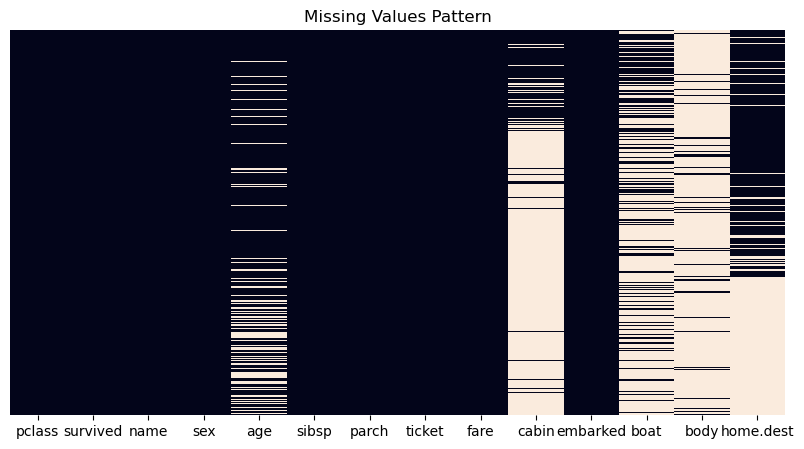

In [12]:
# Visualize missing values

plt.figure(figsize=(10, 5))

sns.heatmap(
    df_raw.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title(
    "Missing Values Pattern"
)

plt.show()

In [13]:
# Target distribution

target = "survived"

counts = (
    df_raw[target]
    .value_counts()
    .sort_index()
)

percentages = (
    df_raw[target]
    .value_counts(
        normalize=True
    )
    .sort_index()
    * 100
)

print("Counts:")
print(counts)

print("\nPercentages:")
print(
    percentages.round(2)
)

Counts:
survived
0    809
1    500
Name: count, dtype: int64

Percentages:
survived
0    61.8
1    38.2
Name: proportion, dtype: float64


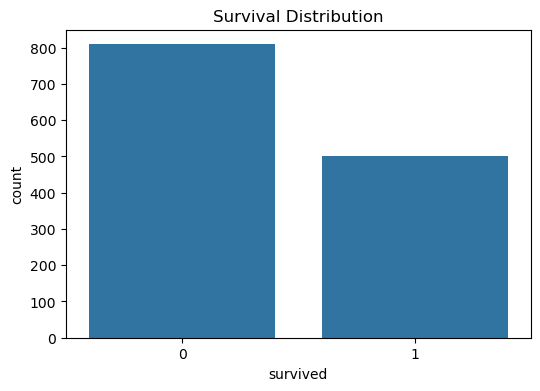

In [14]:
# Plot target balance

plt.figure(
    figsize=(6, 4)
)

sns.countplot(
    data=df_raw,
    x=target
)

plt.title(
    "Survival Distribution"
)

plt.show()

In [15]:
# Select numeric features

numeric_features = (
    df_raw
    .select_dtypes(
        include=np.number
    )
    .columns
    .tolist()
)

print(
    numeric_features
)

['pclass', 'survived', 'age', 'sibsp', 'parch', 'fare', 'body']


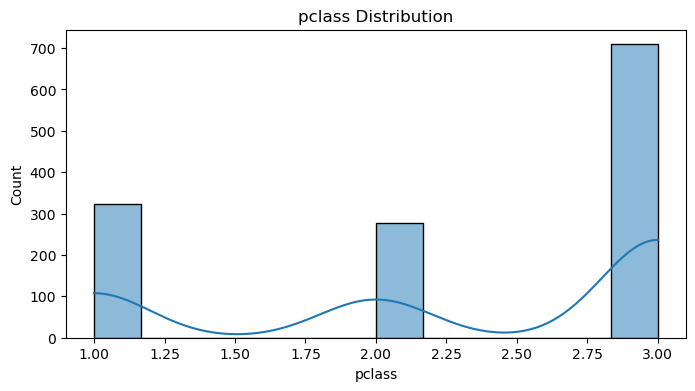

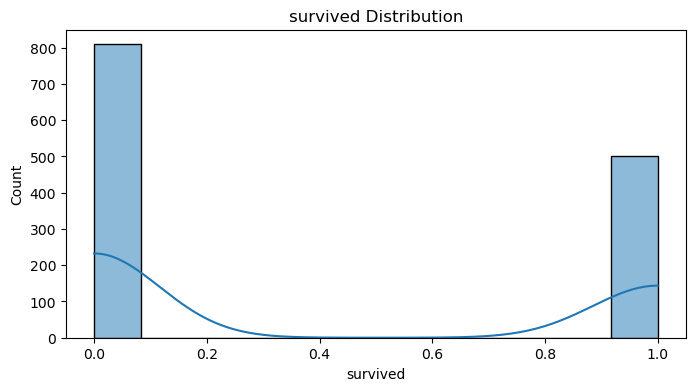

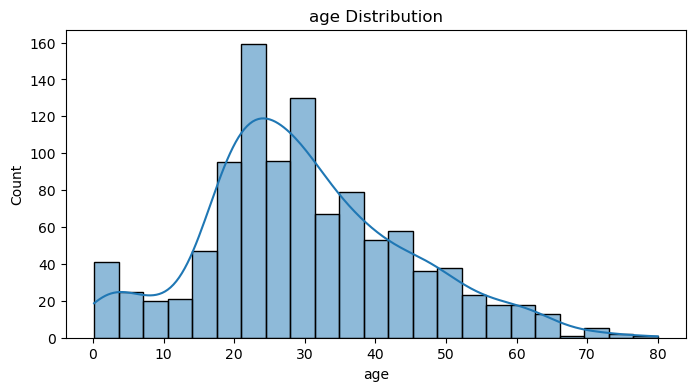

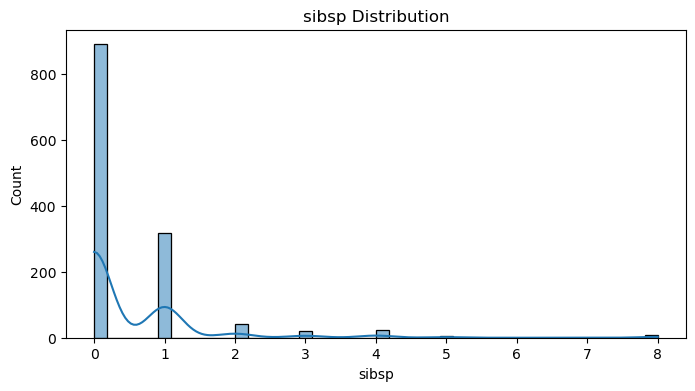

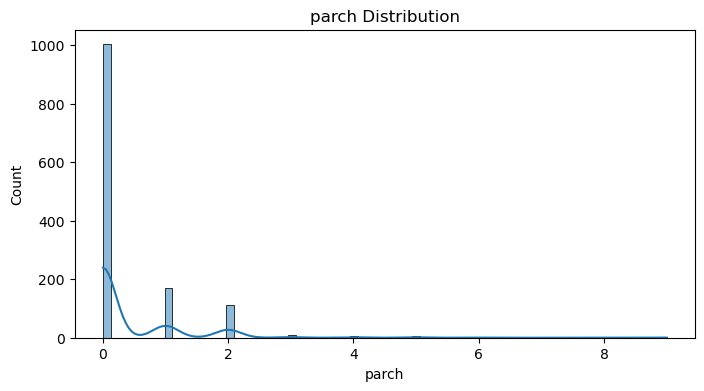

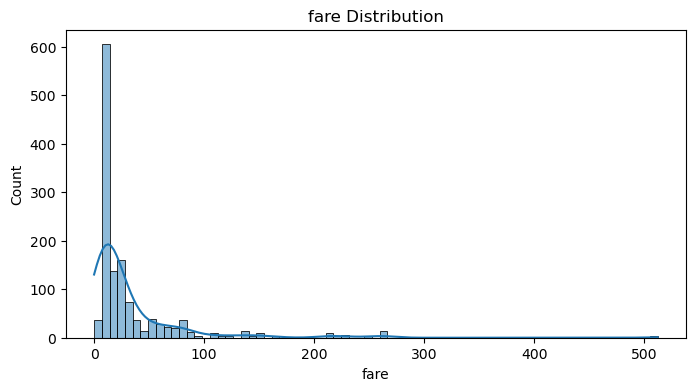

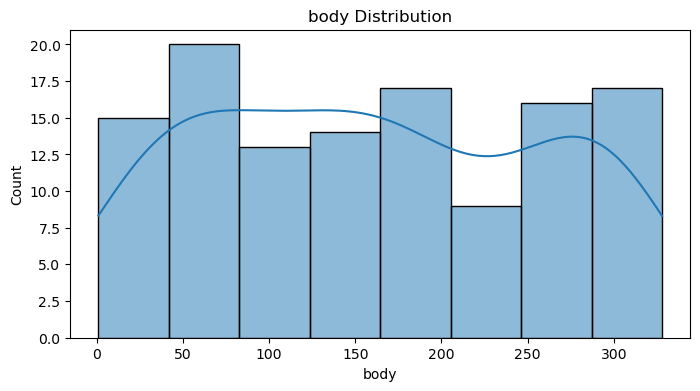

In [16]:
# Plot numeric distributions

for col in numeric_features:

    plt.figure(
        figsize=(8, 4)
    )

    sns.histplot(
        df_raw[col],
        kde=True
    )

    plt.title(
        f"{col} Distribution"
    )

    plt.show()

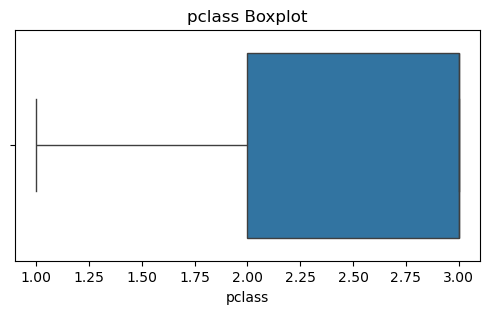

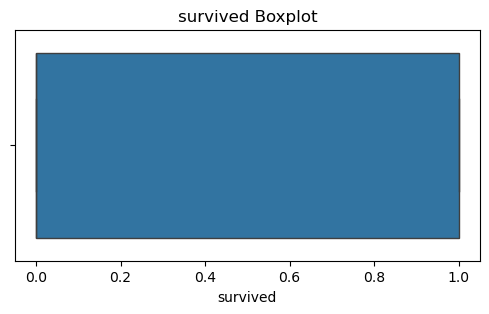

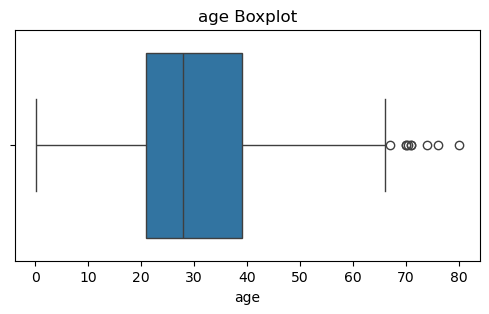

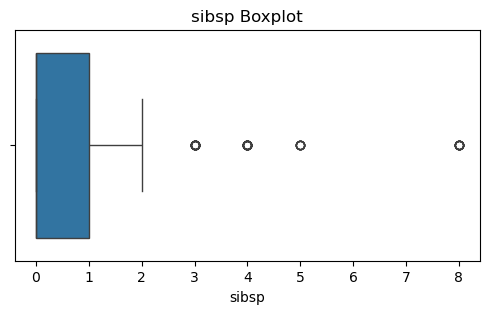

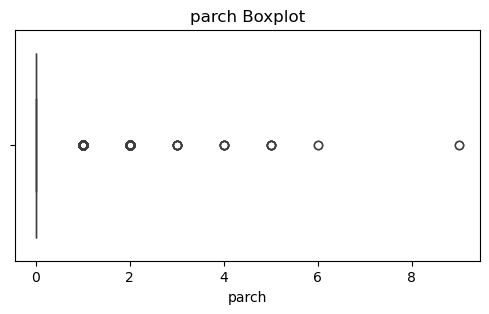

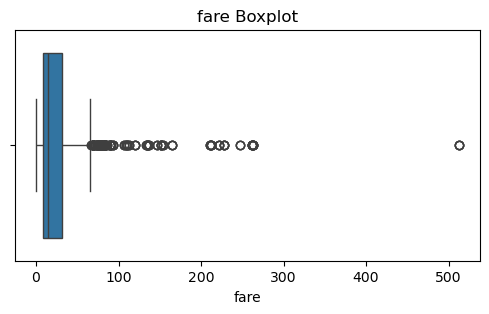

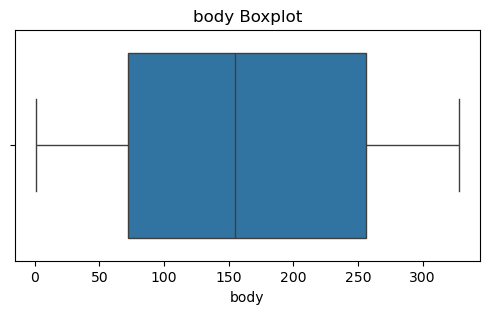

In [17]:
# Check numeric outliers

for col in numeric_features:

    plt.figure(
        figsize=(6, 3)
    )

    sns.boxplot(
        x=df_raw[col]
    )

    plt.title(
        f"{col} Boxplot"
    )

    plt.show()

In [18]:
# Extended numeric statistics

numeric_stats = pd.DataFrame({
    "mean":
        df_raw[
            numeric_features
        ].mean(),

    "median":
        df_raw[
            numeric_features
        ].median(),

    "std":
        df_raw[
            numeric_features
        ].std(),

    "skewness":
        df_raw[
            numeric_features
        ].skew(),

    "kurtosis":
        df_raw[
            numeric_features
        ].kurt()
})

display(
    numeric_stats
)

,mean,median,std,skewness,kurtosis
pclass,2.294882,3.0000,0.837836,-0.598647,-1.315079
survived,0.381971,0.0000,0.486055,0.486404,-1.766112
age,29.881135,28.0000,14.413500,0.407672,0.146950
sibsp,0.498854,0.0000,1.041658,3.844220,20.043251
parch,0.385027,0.0000,0.865560,3.669078,21.541079
fare,33.295479,14.4542,51.758668,4.367709,27.027986
body,160.809917,155.0000,97.696922,0.091739,-1.254052


In [19]:
# Select categorical features

categorical_features = (
    df_raw
    .select_dtypes(
        exclude=np.number
    )
    .columns
    .tolist()
)

print(
    categorical_features
)

['name', 'sex', 'ticket', 'cabin', 'embarked', 'boat', 'home.dest']


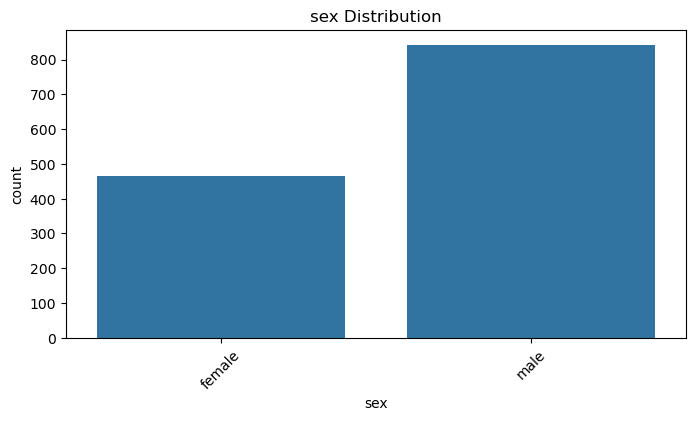

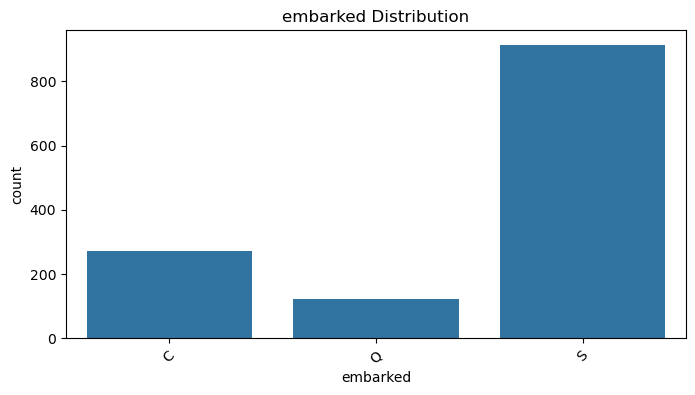

In [20]:
# Plot categorical features

for col in categorical_features:

    if (
        df_raw[col]
        .nunique()
        <= 20
    ):

        plt.figure(
            figsize=(8, 4)
        )

        sns.countplot(
            data=df_raw,
            x=col
        )

        plt.title(
            f"{col} Distribution"
        )

        plt.xticks(
            rotation=45
        )

        plt.show()


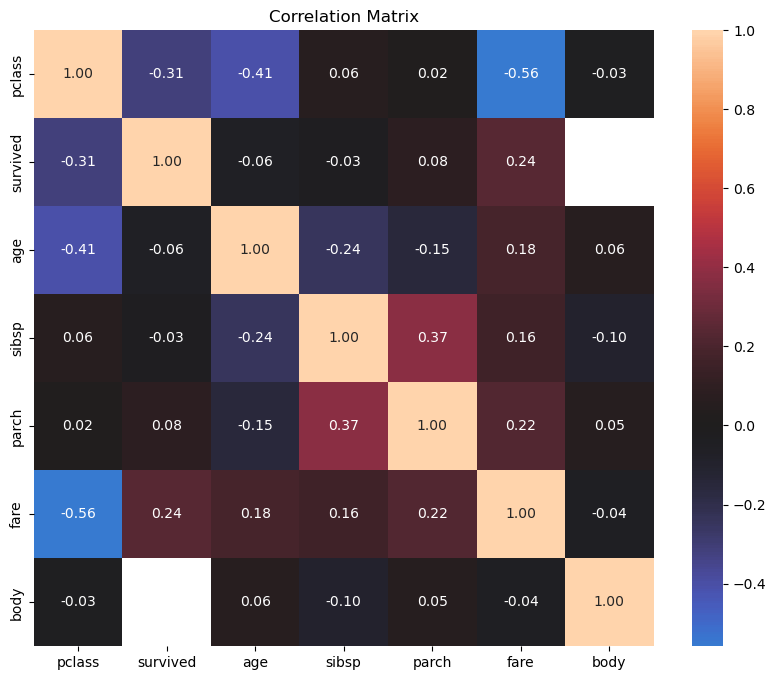

In [21]:
# Numeric correlations

plt.figure(
    figsize=(10, 8)
)

correlation_matrix = (
    df_raw[
        numeric_features
    ]
    .corr()
)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    center=0
)

plt.title(
    "Correlation Matrix"
)

plt.show()

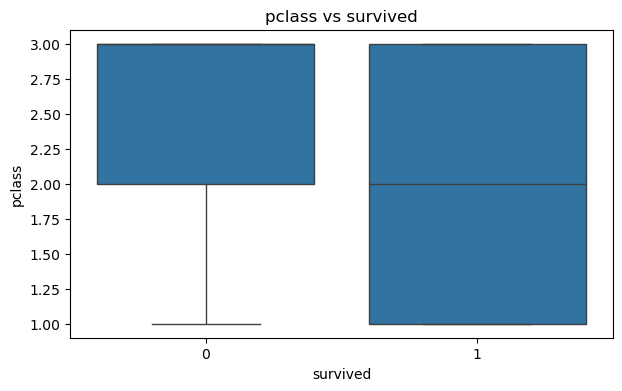

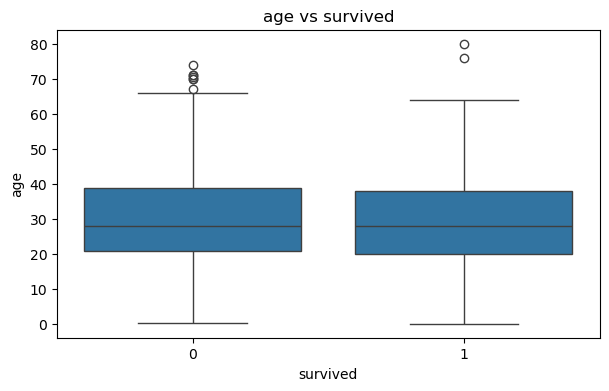

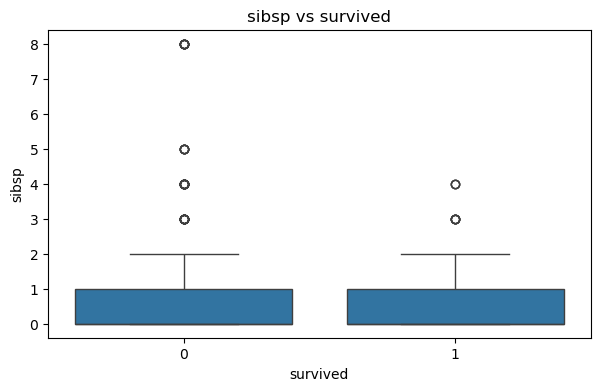

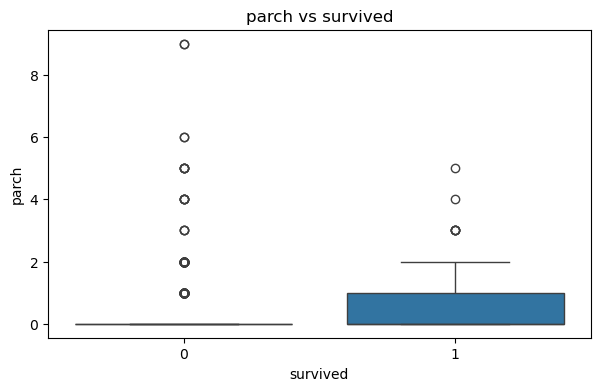

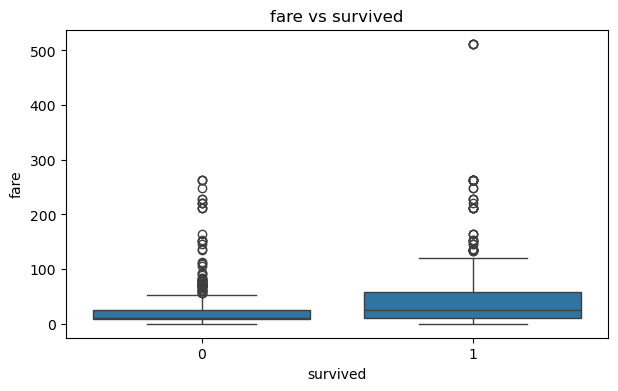

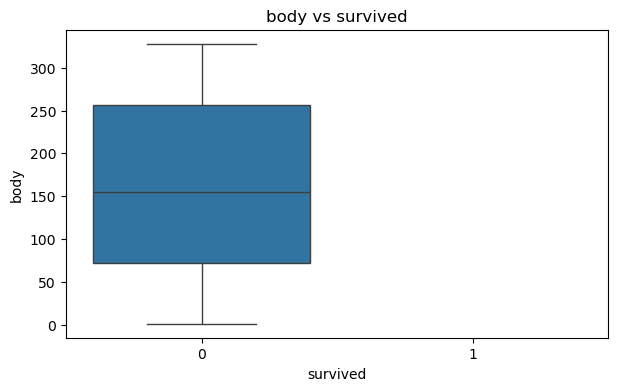

In [22]:
# Compare numeric features with target

for col in numeric_features:

    if col != target:

        plt.figure(
            figsize=(7, 4)
        )

        sns.boxplot(
            data=df_raw,
            x=target,
            y=col
        )

        plt.title(
            f"{col} vs {target}"
        )

        plt.show()

In [23]:
# Compare categories with target

for col in categorical_features:

    if (
        df_raw[col]
        .nunique()
        <= 20
    ):

        survival_rate = (
            df_raw
            .groupby(
                col,
                observed=False
            )[target]
            .mean()
            .sort_values(
                ascending=False
            )
        )

        display(
            survival_rate
        )

sex
female    0.727468
male      0.190985
Name: survived, dtype: float64

embarked
C    0.555556
Q    0.357724
S    0.332604
Name: survived, dtype: float64

In [24]:
# Detect IQR outliers

def outlier_summary(
    data,
    columns
):

    results = []

    for col in columns:

        Q1 = (
            data[col]
            .quantile(0.25)
        )

        Q3 = (
            data[col]
            .quantile(0.75)
        )

        IQR = Q3 - Q1

        lower = (
            Q1 - 1.5 * IQR
        )

        upper = (
            Q3 + 1.5 * IQR
        )

        count = (
            (
                data[col] < lower
            ) |
            (
                data[col] > upper
            )
        ).sum()

        results.append({
            "feature": col,
            "outlier_count": count,
            "lower_bound": lower,
            "upper_bound": upper
        })

    return pd.DataFrame(
        results
    )


display(
    outlier_summary(
        df_raw,
        numeric_features
    )
)

,feature,outlier_count,lower_bound,upper_bound
0,pclass,0,0.500,4.5000
1,survived,0,-1.500,2.5000
2,age,9,-6.000,66.0000
3,sibsp,57,-1.500,2.5000
4,parch,307,0.000,0.0000
5,fare,171,-27.173,66.3438
6,body,0,-204.000,532.0000


In [25]:
# Check Fare distribution

print(
    "Fare skewness:",
    df_raw["fare"]
    .skew()
)

print(
    "Fare kurtosis:",
    df_raw["fare"]
    .kurt()
)

Fare skewness: 4.367709134122922
Fare kurtosis: 27.027986349442294


In [26]:
# Create working dataset

df = df_raw.copy()


# ===== Code Cell 26 =====
# Create family features

df["FamilySize"] = (
    df["sibsp"]
    + df["parch"]
    + 1
)

df["IsAlone"] = (
    df["FamilySize"] == 1
).astype(int)

display(
    df[
        [
            "sibsp",
            "parch",
            "FamilySize",
            "IsAlone"
        ]
    ]
    .head()
)

,sibsp,parch,FamilySize,IsAlone
0,0,0,1,1
1,1,2,4,0
2,1,2,4,0
3,1,2,4,0
4,1,2,4,0


In [27]:
# Create cabin indicator

df["Has_Cabin"] = (
    df["cabin"]
    .notna()
    .astype(int)
)

print(
    df[
        "Has_Cabin"
    ].value_counts()
)

Has_Cabin
0    1014
1     295
Name: count, dtype: int64


In [28]:
# Extract passenger title

df["Title"] = (
    df["name"]
    .str.extract(
        r",\s*([^.]*)\."
    )[0]
)

print(
    df["Title"]
    .value_counts()
)

Title
Mr              757
Miss            260
Mrs             197
Master           61
Dr                8
Rev               8
Col               4
Major             2
Mlle              2
Ms                2
Mme               1
Capt              1
Lady              1
Sir               1
Dona              1
Jonkheer          1
the Countess      1
Don               1
Name: count, dtype: int64


In [29]:
# Group rare titles

common_titles = [
    "Mr",
    "Miss",
    "Mrs",
    "Master"
]

df["Title"] = (
    df["Title"]
    .where(
        df["Title"]
        .isin(
            common_titles
        ),
        "Rare"
    )
)

print(
    df["Title"]
    .value_counts()
)

Title
Mr        757
Miss      260
Mrs       197
Master     61
Rare       34
Name: count, dtype: int64


In [30]:
# Count ticket group size

df["TicketGroupSize"] = (
    df.groupby(
        "ticket"
    )["ticket"]
    .transform(
        "count"
    )
)

display(
    df[
        [
            "ticket",
            "TicketGroupSize"
        ]
    ]
    .head()
)

,ticket,TicketGroupSize
0,24160,4
1,113781,6
2,113781,6
3,113781,6
4,113781,6


In [31]:
# Log transform Fare

df["Fare_log"] = np.log1p(
    df["fare"]
)

print(
    "Original skew:",
    df["fare"]
    .skew()
)

print(
    "Log skew:",
    df["Fare_log"]
    .skew()
)

Original skew: 4.367709134122922
Log skew: 0.5418884978395566


In [32]:
#Check invalid values

checks = {
    "Age negative":
        (df["age"] < 0).sum(),

    "Fare negative":
        (df["fare"] < 0).sum(),

    "Invalid target":
        (~df["survived"].isin([0, 1]))
        .sum()
}

print(checks)


{'Age negative': np.int64(0), 'Fare negative': np.int64(0), 'Invalid target': np.int64(0)}


In [33]:
# Drop raw identifiers

drop_columns = [
    "name",
    "ticket",
    "cabin",
    "boat",
    "body",
    "home.dest"
]

df = df.drop(
    columns=drop_columns,
    errors="ignore"
)

print(
    df.shape
)

display(
    df.head()
)

(1309, 14)


,pclass,survived,sex,age,sibsp,parch,fare,embarked,FamilySize,IsAlone,Has_Cabin,Title,TicketGroupSize,Fare_log
0,1,1,female,29.0000,0,0,211.3375,S,1,1,1,Miss,4,5.358177
1,1,1,male,0.9167,1,2,151.5500,S,4,0,1,Master,6,5.027492
2,1,0,female,2.0000,1,2,151.5500,S,4,0,1,Miss,6,5.027492
3,1,0,male,30.0000,1,2,151.5500,S,4,0,1,Mr,6,5.027492
4,1,0,female,25.0000,1,2,151.5500,S,4,0,1,Mrs,6,5.027492


In [34]:
#Separate features and target

X = df.drop(
    columns="survived"
)

y = df["survived"]

print(
    "X shape:",
    X.shape
)

print(
    "y shape:",
    y.shape
)

X shape: (1309, 13)
y shape: (1309,)


In [35]:
# Final dataset check

print("Shape:", df.shape)

print("\nMissing values:")
display(
    df.isnull().sum()
    .sort_values(ascending=False)
)

print("\nData types:")
display(df.dtypes)

print("\nTarget distribution:")
display(
    df["survived"]
    .value_counts()
    .sort_index()
)

Shape: (1309, 14)

Missing values:


age                263
embarked             2
fare                 1
Fare_log             1
pclass               0
survived             0
sex                  0
sibsp                0
parch                0
FamilySize           0
IsAlone              0
Has_Cabin            0
Title                0
TicketGroupSize      0
dtype: int64


Data types:


pclass                int64
survived              int64
sex                category
age                 float64
sibsp                 int64
parch                 int64
fare                float64
embarked           category
FamilySize            int64
IsAlone               int64
Has_Cabin             int64
Title                   str
TicketGroupSize       int64
Fare_log            float64
dtype: object


Target distribution:


survived
0    809
1    500
Name: count, dtype: int64

In [36]:
# Final features

print("Features:")
print(X.columns.tolist())

print("\nNumeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Features:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'FamilySize', 'IsAlone', 'Has_Cabin', 'Title', 'TicketGroupSize', 'Fare_log']

Numeric features:
['pclass', 'survived', 'age', 'sibsp', 'parch', 'fare', 'body']

Categorical features:
['name', 'sex', 'ticket', 'cabin', 'embarked', 'boat', 'home.dest']


In [37]:
# Final feature dataset

ml_df = df.copy()

print(
    "ML-ready shape:",
    ml_df.shape
)

display(
    ml_df.head()
)

ML-ready shape: (1309, 14)


,pclass,survived,sex,age,sibsp,parch,fare,embarked,FamilySize,IsAlone,Has_Cabin,Title,TicketGroupSize,Fare_log
0,1,1,female,29.0000,0,0,211.3375,S,1,1,1,Miss,4,5.358177
1,1,1,male,0.9167,1,2,151.5500,S,4,0,1,Master,6,5.027492
2,1,0,female,2.0000,1,2,151.5500,S,4,0,1,Miss,6,5.027492
3,1,0,male,30.0000,1,2,151.5500,S,4,0,1,Mr,6,5.027492
4,1,0,female,25.0000,1,2,151.5500,S,4,0,1,Mrs,6,5.027492


In [38]:
# Leakage check

possible_leakage = [
    "boat",
    "body",
    "survived"
]

print("Leakage-related columns:")

for col in possible_leakage:
    if col in ml_df.columns:
        print(col)

Leakage-related columns:
survived


In [39]:
# Save analysis output

output_path = "titanic_ml_ready.csv"

ml_df.to_csv(
    output_path,
    index=False
)

print(
    f"Saved: {output_path}"
)

Saved: titanic_ml_ready.csv


In [40]:
# Verify saved dataset

test_df = pd.read_csv(
    "titanic_ml_ready.csv"
)

print(
    "Shape:",
    test_df.shape
)

display(
    test_df.head()
)


Shape: (1309, 14)


,pclass,survived,sex,age,sibsp,parch,fare,embarked,FamilySize,IsAlone,Has_Cabin,Title,TicketGroupSize,Fare_log
0,1,1,female,29.0000,0,0,211.3375,S,1,1,1,Miss,4,5.358177
1,1,1,male,0.9167,1,2,151.5500,S,4,0,1,Master,6,5.027492
2,1,0,female,2.0000,1,2,151.5500,S,4,0,1,Miss,6,5.027492
3,1,0,male,30.0000,1,2,151.5500,S,4,0,1,Mr,6,5.027492
4,1,0,female,25.0000,1,2,151.5500,S,4,0,1,Mrs,6,5.027492
